# **Análisis de Preferencias Regionales y Optimización de Estrategia de Marketing para Videojuegos de la plataforma PlayStation 4**
### El mercado de los videojuegos ha tenido un gran auge en los últimos años, se ha democratizado su acceso a gran parte de la población, en distintas plataformas, géneros y temáticas.
### El consumidor de videojuegos ya no se trata solo de niños de clase media-alta, sino que se expande a todas las edades y demografías. 
### Es por este rápido crecimiento que las compañias desarrolladoras han buscado constantemente innovar para ser más atrayentes para este creciente mercado, ofreciendo plataformas con mayores capacidades tecnológicas, juegos con historias inmersivas, mejores gráficos, disponibilidad para uno o multiples jugadores, y así una lista sin fin de caracteristicas.
### Por esta razón me parecio de gran interés poder caracterizar las ventas de videojuegos en el mundo. Para ello se tomó el dataset "Video Games Sales Dataset" de la plataforma Kaggle.com que incluye tres documentos csv:
>          -"Video_Games_Sales_as_at_22_Dec_2016.
>          -"PS4_GamesSales.csv"
>          -"XboxOne_GameSales"

### Para este análisis solo serán considerados los datos relativos a las ventas para la consola Playstation 4

# **Etapa 1: Ask (Hacer preguntas)**

## **1.1. El Problema de Negocio (Business Case)**
### "Nuestra compañía opera en el mercado global de videojuegos y necesita optimizar su inversión en marketing. Actualmente, existe una asignación de recursos genérica que no considera las diferencias culturales y de preferencia entre regiones clave como Norteamérica, Europa y Japón. Si no alineamos nuestra inversión de marketing y nuestros esfuerzos de adquisición de contenido con los géneros que realmente dominan las ventas en cada región, corremos el riesgo de perder eficiencia y rentabilidad.
## **1.2. El Objetivo de Negocio**
### "El objetivo principal de este análisis es proporcionar evidencia cuantitativa a los equipos de Marketing y Distribución para que puedan re-enfocar la estrategia de inversión. Específicamente, buscamos identificar el género de videojuego dominante en cada una de las principales regiones para guiar decisiones sobre el presupuesto publicitario y las licencias de nuevos títulos.
## **1.3. Preguntas SMART a responder:**
### "¿Cuáles son los 5 géneros de videojuegos más popular en términos de volumen absoluto de ventas en Norteamérica, Europa y Japón basado en los datos de ventas de PS4, y cómo debería la compañía re-priorizar su presupuesto de marketing entre los 10 géneros principales para el próximo ciclo de inversión?"
### "Considerando los 10 principales desarrolladores por volumen total de ventas, ¿cuál es su eficiencia de producción medida por el promedio de ventas globales por título publicado? Y, en base a esta eficiencia, ¿qué Publishers deben priorizarse para futuras licencias o acuerdos de inversión, y cuáles deben revisarse o descartarse?"

# **Etapa 2: Preparar (disponer y entender los datos)**
>Obtener y Cargar Dataframe
> Tamaño del Dataframe (shape)
 Inicio y fin (head and tail
 tipos de datos y número de datos nulos (dtypes - info)
 descripción estadística de datos (describe)


## 2.0. carga de librerias

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')
#pd.set_option('max_columns',200)


## 2.1. Carga del DataFrame a partir de un documento CSV

In [127]:
df=pd.read_csv("PS4_GamesSales.csv",encoding='latin-1')

## 2.2. Revisión preeliminar del DataFrame

In [4]:
print('--- Número de filas y columnas contenidos en el DataFrame (df.shape)---')
print(df.shape)

--- Número de filas y columnas contenidos en el DataFrame (df.shape)---
(1034, 9)


In [5]:
print(df.columns)

Index(['Game', 'Year', 'Genre', 'Publisher', 'North America', 'Europe',
       'Japan', 'Rest of World', 'Global'],
      dtype='object')


In [6]:
# Las columnas nos indican el nombre del juego, el año en que se publicó, el género al que pertenece, quién lo publicó y los datos de ventas en millones de unidades vendidas por región

In [7]:

print ('--- Inspección primeras filas (df.head())---\n')
print(df.head())

--- Inspección primeras filas (df.head())---

                        Game    Year             Genre       Publisher  \
0         Grand Theft Auto V  2014.0            Action  Rockstar Games   
1  Call of Duty: Black Ops 3  2015.0           Shooter      Activision   
2      Red Dead Redemption 2  2018.0  Action-Adventure  Rockstar Games   
3         Call of Duty: WWII  2017.0           Shooter      Activision   
4                    FIFA 18  2017.0            Sports       EA Sports   

   North America  Europe  Japan  Rest of World  Global  
0           6.06    9.71   0.60           3.02   19.39  
1           6.18    6.05   0.41           2.44   15.09  
2           5.26    6.21   0.21           2.26   13.94  
3           4.67    6.21   0.40           2.12   13.40  
4           1.27    8.64   0.15           1.73   11.80  


In [8]:

print('--- inspección últimas filas (df.tail()) ---\n')
print(df.tail())

--- inspección últimas filas (df.tail()) ---

                                    Game    Year         Genre      Publisher  \
1029  Fallen Legion: Flames of Rebellion     NaN  Role-Playing            NaN   
1030            Radial G Racing Revolved  2017.0        Racing  Tammeka Games   
1031                The Mummy Demastered     NaN        Action            NaN   
1032          Project Nimbus: Code Mirai     NaN        Action            NaN   
1033                 Battle Chef Brigade     NaN        Action            NaN   

      North America  Europe  Japan  Rest of World  Global  
1029            0.0     0.0    0.0            0.0     0.0  
1030            0.0     0.0    0.0            0.0     0.0  
1031            0.0     0.0    0.0            0.0     0.0  
1032            0.0     0.0    0.0            0.0     0.0  
1033            0.0     0.0    0.0            0.0     0.0  


In [9]:
print('---Géneros incluidos en los datos ---\n')
print(df['Genre'].unique())


---Géneros incluidos en los datos ---

['Action' 'Shooter' 'Action-Adventure' 'Sports' 'Role-Playing' 'Misc'
 'Platform' 'Racing' 'Fighting' 'Adventure' 'MMO' 'Simulation' 'Music'
 'Party' 'Strategy' 'Puzzle' 'Visual Novel']


In [10]:
print('--- Empresas desarrolladoras incluidas--- \n')
print(df['Publisher'].unique())


--- Empresas desarrolladoras incluidas--- 

['Rockstar Games' 'Activision' 'EA Sports' 'Electronic Arts'
 'Sony Interactive Entertainment' 'Bethesda Softworks'
 'Sony Computer Entertainment' 'Namco Bandai Games' 'Square Enix' 'Capcom'
 'Blizzard Entertainment' 'Ubisoft' 'Warner Bros. Interactive' '2K Sports'
 'Warner Bros. Interactive Entertainment' 'Konami Digital Entertainment'
 '2K Games' 'Hello Games' '505 Games' 'Deep Silver' 'Take-Two Interactive'
 'Bandai Namco Games' 'Sega' 'Tecmo Koei' 'Gearbox Software' 'Mojang'
 'Disney Interactive Studios' 'Focus Home Interactive' 'Studio Wildcard'
 'Codemasters' 'Koch Media' 'Harmonix Music Systems'
 'Rebellion Developments' 'Gun Media' 'Telltale Games' 'Kalypso Media'
 'City Interactive' 'NIS America' 'Sold Out' 'Tripwire Interactive'
 'PQube' 'THQ Nordic' 'Milestone S.r.l.' 'Nordic Games' 'Astragon'
 'Koei Tecmo' 'Frontier Developments' 'Marvelous Interactive'
 'Arc System Works' 'Milestone' 'Milestone S.r.l' 'System 3'
 'Paradox Interac

In [11]:
print('---Tipos de datos por columna---\n')
df.dtypes

---Tipos de datos por columna---



Game              object
Year             float64
Genre             object
Publisher         object
North America    float64
Europe           float64
Japan            float64
Rest of World    float64
Global           float64
dtype: object

In [12]:
#La columna Year debiese ser un número entero del tipo int o bien un string

In [13]:
print('--- información general ---\n')
df.info()

--- información general ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1034 entries, 0 to 1033
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Game           1034 non-null   object 
 1   Year           825 non-null    float64
 2   Genre          1034 non-null   object 
 3   Publisher      825 non-null    object 
 4   North America  1034 non-null   float64
 5   Europe         1034 non-null   float64
 6   Japan          1034 non-null   float64
 7   Rest of World  1034 non-null   float64
 8   Global         1034 non-null   float64
dtypes: float64(6), object(3)
memory usage: 72.8+ KB


In [14]:
# Los datos nulos provenientes de las columnas Year y Publisher deberán tratarse en la próxima etapa

# **Etapa 3: Procesar (Garantizar la calidad de los datos)**

>°Eliminar filas y columnas irrelevantes para el análisis* (Crear un subset o drop)
>°Identificar columnas duplicadas* (df.duplicated, df.duplicated(df[subset='...']))
> °Dar formato correcto a los datos y nombres de columnas(to_numeric, to_datetime, to_boolean, etc)
>°Manipulación de nulos* (isna().sum(), dropna)
>°Trabajar con filas en específico (loc[], iloc[])

## 3.1. Exploración estadística preeliminar

In [15]:
df.describe()

,Year,North America,Europe,Japan,Rest of World,Global
count,825.000000,1034.000000,1034.000000,1034.000000,1034.000000,1034.000000
mean,2015.966061,0.204613,0.248714,0.033636,0.089014,0.576054
std,1.298360,0.563471,0.785491,0.108344,0.249410,1.583534
min,2013.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2016.000000,0.020000,0.000000,0.000000,0.010000,0.060000
75%,2017.000000,0.120000,0.130000,0.030000,0.050000,0.357500
max,2020.000000,6.180000,9.710000,2.170000,3.020000,19.390000


In [16]:
#Al observar este resumen, se puede apreciar que todos los valores máximos distan bastante de la media de ventas por región, se realizará un análisis de Outliers para más detalles
#Por otro lado, no se observan valores que puedan dar indicios de errores en los datos como valores negativos 

## 3.2. Búsqueda de valores atípicos

Text(0.5, 0, 'Millones de unidades vendidas')

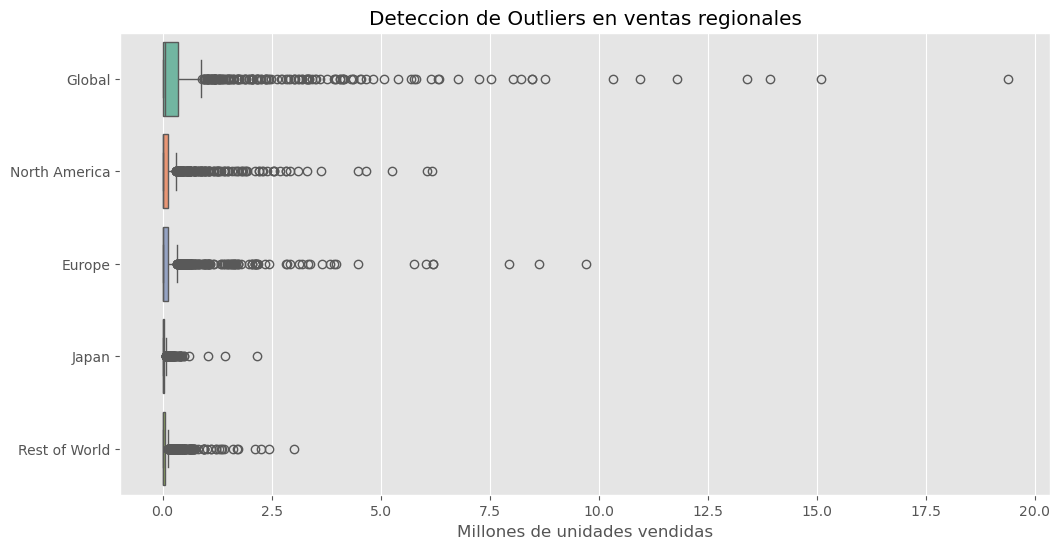

In [17]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Global','North America','Europe','Japan','Rest of World']],orient='h', palette='Set2')
plt.title('Deteccion de Outliers en ventas regionales')
plt.xlabel('Millones de unidades vendidas')

In [18]:
# Calculo de Rango Inter-cuartil
Q1=df['Global'].quantile(0.25)
Q3=df['Global'].quantile(0.75)
RIC=Q3-Q1

#Calculo de límite superior
Limite_superior=Q3+1.5*RIC
Outliers=df[df['Global']>Limite_superior].sort_values(by='Global',ascending=False)
print(f'Límite superior para outliers: {Limite_superior:.2f} Millones de unidades vendidas')
print('\n ---principales juegos con ventas atípicas a nivel global---')
print(Outliers[['Game','Global','Publisher','Genre']].head(10))

Límite superior para outliers: 0.89 Millones de unidades vendidas

 ---principales juegos con ventas atípicas a nivel global---
                             Game  Global                       Publisher  \
0              Grand Theft Auto V   19.39                  Rockstar Games   
1       Call of Duty: Black Ops 3   15.09                      Activision   
2           Red Dead Redemption 2   13.94                  Rockstar Games   
3              Call of Duty: WWII   13.40                      Activision   
4                         FIFA 18   11.80                       EA Sports   
5                         FIFA 17   10.94                 Electronic Arts   
6                 Uncharted (PS4)   10.33  Sony Interactive Entertainment   
7                Spider-Man (PS4)    8.76  Sony Interactive Entertainment   
9                       Fallout 4    8.48              Bethesda Softworks   
8  Call of Duty: Infinite Warfare    8.48                      Activision   

              Genre  
0 

In [19]:
#En este caso la presencia de outliers representa una norma en la industria, por lo tanto se conservarán aunque se sugiera realizar una clasificación para una mejor manipulación en la fase de Análisis

## 3.3. Tratamiento de Duplicados

In [20]:
print('Número de filas duplicadas en su totalidad', {df.duplicated().sum()})
print('Número de juegos duplicados por su nombre inicialmente', {df.duplicated(subset='Game').sum()})
df[df['Game'].duplicated(keep=False)].sort_values('Game')

Número de filas duplicadas en su totalidad {0}
Número de juegos duplicados por su nombre inicialmente {3}


,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
775,Apotheon,NaN,Platform,NaN,0.0,0.0,0.0,0.0,0.0
963,Apotheon,NaN,Action,NaN,0.0,0.0,0.0,0.0,0.0
1024,Biomutant,2018.0,Action,THQ Nordic,0.0,0.0,0.0,0.0,0.0
1025,Biomutant,2019.0,Action,THQ Nordic,0.0,0.0,0.0,0.0,0.0
717,War Thunder,2017.0,Action,DMM Games,0.0,0.0,0.0,0.0,0.0
796,War Thunder,NaN,Misc,NaN,0.0,0.0,0.0,0.0,0.0


In [21]:
#En este caso no existen filas duplicadas en su totalidad
#Sin embargo, existen tres juegos que presentan el mismo nombre, para este caso se conservará aquel que contenga más campos completos o tenga mayor antigüedad

In [22]:
df.drop_duplicates(subset=['Game'],keep='first',inplace=True)

In [23]:
df[df['Game'].duplicated(keep=False)].sort_values('Game')

,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global


In [24]:
# Se comprueba que los juegos duplicados fueron eliminados

## 3.4. Tratamiento de valores Nulos

In [25]:
df.isna().sum()

Game               0
Year             207
Genre              0
Publisher        207
North America      0
Europe             0
Japan              0
Rest of World      0
Global             0
dtype: int64

In [26]:
# se observa la existencia de 207 valores nulos tanto en la columna Year y Publisher ya que será considerado para un próximo análisis, se decide eliminar los valores nulos para que no produzcan un sesgo en el análisis

In [27]:
df=df.dropna(subset=['Publisher'])

In [28]:
df.isna().sum()

Game             0
Year             0
Genre            0
Publisher        0
North America    0
Europe           0
Japan            0
Rest of World    0
Global           0
dtype: int64

In [29]:
#como consecuencia de lo anterior también se eliminan las filas con el campo Year en nulo, ahora contamos con un data frame limpio

## 3.5. Estandarización de cadenas

In [30]:
df['Genre']=df['Genre'].astype(str).str.strip().str.upper()
df['Publisher']=df['Publisher'].astype(str).str.strip().str.upper()
print('Los géneros de videojuegos únicos existentes en los datos son:')
df['Genre'].unique()

print('Los Desarrolladores de videojuegos únicos existentes en los datos son:')
df['Publisher'].unique()

Los géneros de videojuegos únicos existentes en los datos son:
Los Desarrolladores de videojuegos únicos existentes en los datos son:


array(['ROCKSTAR GAMES', 'ACTIVISION', 'EA SPORTS', 'ELECTRONIC ARTS',
       'SONY INTERACTIVE ENTERTAINMENT', 'BETHESDA SOFTWORKS',
       'SONY COMPUTER ENTERTAINMENT', 'NAMCO BANDAI GAMES', 'SQUARE ENIX',
       'CAPCOM', 'BLIZZARD ENTERTAINMENT', 'UBISOFT',
       'WARNER BROS. INTERACTIVE', '2K SPORTS',
       'WARNER BROS. INTERACTIVE ENTERTAINMENT',
       'KONAMI DIGITAL ENTERTAINMENT', '2K GAMES', 'HELLO GAMES',
       '505 GAMES', 'DEEP SILVER', 'TAKE-TWO INTERACTIVE',
       'BANDAI NAMCO GAMES', 'SEGA', 'TECMO KOEI', 'GEARBOX SOFTWARE',
       'MOJANG', 'DISNEY INTERACTIVE STUDIOS', 'FOCUS HOME INTERACTIVE',
       'STUDIO WILDCARD', 'CODEMASTERS', 'KOCH MEDIA',
       'HARMONIX MUSIC SYSTEMS', 'REBELLION DEVELOPMENTS', 'GUN MEDIA',
       'TELLTALE GAMES', 'KALYPSO MEDIA', 'CITY INTERACTIVE',
       'NIS AMERICA', 'SOLD OUT', 'TRIPWIRE INTERACTIVE', 'PQUBE',
       'THQ NORDIC', 'MILESTONE S.R.L.', 'NORDIC GAMES', 'ASTRAGON',
       'KOEI TECMO', 'FRONTIER DEVELOPMENTS', 

## 3.6. Conversión de tipo de datos

In [31]:
df.head()

,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,Grand Theft Auto V,2014.0,ACTION,ROCKSTAR GAMES,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,2015.0,SHOOTER,ACTIVISION,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,2018.0,ACTION-ADVENTURE,ROCKSTAR GAMES,5.26,6.21,0.21,2.26,13.94
3,Call of Duty: WWII,2017.0,SHOOTER,ACTIVISION,4.67,6.21,0.40,2.12,13.40
4,FIFA 18,2017.0,SPORTS,EA SPORTS,1.27,8.64,0.15,1.73,11.80


In [32]:
#df['Year'] = pd.to_numeric(df['Year'], errors='coerce').fillna(0) #convierte los datos de la columna Year a numérico y los valores NaN a 0 
df['Year']=df['Year'].astype(int) #convierte a valores enteros los años

In [ ]:
# La columna Year se convirtió de un tipo float64 a int para facilitar su interpretación

In [33]:
df.shape

(824, 9)

# **Etapa 4: Analizar**

## 4.1. *Pregunta 1: Preferencias por región y género*

### 4.1.1. Análisis 1: Preferencias por Género y Región (Volumen Absoluto)

#### Aquí cuantificamos la popularidad de los géneros para responder a la pregunta de "qué vender" en términos de volumen

In [34]:
Genres=df.groupby('Genre')[['Global','North America','Europe','Rest of World','Japan']].sum().sort_values(by='Global',ascending=False).reset_index()
top_genres=Genres.head(10)
print(top_genres)
df_genres_long=top_genres.melt(id_vars='Genre',value_vars=['North America','Europe','Rest of World','Japan'],var_name='Region',value_name='Million of Units') #df en formato largo, será más simple para futuras visualizaciones


              Genre  Global  North America  Europe  Rest of World  Japan
0            ACTION  136.82          48.15   57.51          20.76  10.27
1           SHOOTER  134.99          50.50   58.64          21.48   4.42
2            SPORTS   92.85          33.31   42.81          14.90   1.83
3      ROLE-PLAYING   62.73          22.15   22.40           8.91   9.33
4  ACTION-ADVENTURE   61.86          22.30   27.79           9.83   1.96
5            RACING   25.29           5.86   14.77           3.81   0.76
6          FIGHTING   19.36           8.58    6.11           2.97   1.67
7          PLATFORM   17.85           5.48    8.92           2.77   0.67
8         ADVENTURE   15.22           5.27    6.08           2.23   1.64
9              MISC   12.47           3.64    6.03           1.85   0.96


### 4.1.2. Análisis 2: Contribución Regional por Género (Porcentaje)

#### Evaluamos la importancia relativa de cada región en el éxito de un género

In [35]:
contribucion_region=top_genres.copy()
columnas_region=['North America','Europe','Rest of World', 'Japan']
# Crear una columna con los aportes porcentuales por género para cada una de las regiones listadas en la línea anterior
for col in columnas_region:
    contribucion_region[f'Pct_{col}']=contribucion_region[col]/contribucion_region['Global']*100

columnas_pct = [f'Pct_{col}' for col in columnas_region]

df_porcentaje_long=contribucion_region.melt(id_vars='Genre',value_vars=columnas_pct,var_name='Region',value_name='contribucion_region')

# limpiar el nombre para eliminar la palabra pct 
df_porcentaje_long['Region']=df_porcentaje_long['Region'].str.replace('Pct_', '',regex=False)
print(df_porcentaje_long)

verificacion_suma=df_porcentaje_long.groupby('Genre')['contribucion_region'].sum().reset_index()
verificacion_suma.rename(columns={'contribucion_region':'Suma_Total_contribucion'},inplace=True)
print(verificacion_suma)

               Genre         Region  contribucion_region
0             ACTION  North America            35.192223
1            SHOOTER  North America            37.410179
2             SPORTS  North America            35.875067
3       ROLE-PLAYING  North America            35.310059
4   ACTION-ADVENTURE  North America            36.049143
5             RACING  North America            23.171214
6           FIGHTING  North America            44.318182
7           PLATFORM  North America            30.700280
8          ADVENTURE  North America            34.625493
9               MISC  North America            29.190056
10            ACTION         Europe            42.033328
11           SHOOTER         Europe            43.440255
12            SPORTS         Europe            46.106624
13      ROLE-PLAYING         Europe            35.708592
14  ACTION-ADVENTURE         Europe            44.924022
15            RACING         Europe            58.402531
16          FIGHTING         Eu

## 4.2. Pregunta 2: Eficiencia de Publishers - títulos más y menos exitosos

### 4.2.1. Análisis 3: Eficiencia de Publishers

#### Identificar a los desarrolladores más **eficientes** midiendo las ventas globales promedio por título publicado.

In [118]:
eficiencia_publishers=df.groupby('Publisher').agg(Num_Titulos=('Game','count'), 
                                                  Ventas_Globales_Total=('Global','sum'),
                                                  Ventas_Globales_Mediana=('Global','median'))
print(eficiencia_publishers)

                                        Num_Titulos  Ventas_Globales_Total  \
Publisher                                                                    
2K GAMES                                          7                   8.03   
2K SPORTS                                         7                  17.36   
3D REALMS                                         1                   0.00   
505 GAMES                                        16                   4.19   
5PB                                               8                   0.12   
...                                             ...                    ...   
WARNER BROS. INTERACTIVE ENTERTAINMENT           27                  27.83   
WIRED PRODUCTIONS                                 3                   0.08   
XSEED GAMES                                       1                   0.08   
YACHT CLUB GAMES                                  1                   0.14   
YETI                                              1             

In [121]:
eficiencia_publishers=eficiencia_publishers[eficiencia_publishers['Num_Titulos']>=5]

In [122]:
publishers_top_eficientes=eficiencia_publishers.sort_values(by='Ventas_Globales_Mediana',ascending=False).head(10)
publishers_top_eficientes

,Num_Titulos,Ventas_Globales_Total,Ventas_Globales_Mediana
Publisher,,,
2K SPORTS,7,17.36,2.490
ELECTRONIC ARTS,21,54.96,1.720
BETHESDA SOFTWORKS,17,28.96,1.130
2K GAMES,7,8.03,1.010
EA SPORTS,19,47.55,0.970
SONY COMPUTER ENTERTAINMENT,25,42.26,0.960
WARNER BROS. INTERACTIVE ENTERTAINMENT,27,27.83,0.940
KONAMI DIGITAL ENTERTAINMENT,12,8.39,0.530
CODEMASTERS,6,2.68,0.500


In [43]:
# Los desarrolladores más eficientes son aquellos que tienen una mediana de ventas más alta, esto debido a las particularidades de la industria de los videojuegos y la existencia de juegos 'Best Sellers'
#El promedio en este caso disfrazaría como una medida de éxito constante a un desarrollador que pudo haber tenido un golpe de suerte. De este modo se privilegia la consistencia en la calidad de los mismos.


### 4.2.2. Análisis 4: Clasificación ABC Pareto de los titulos

In [44]:
#Crea una copia del data frame solo con las columnas a utilizar
df_pareto=df[['Game','Global']].copy()

In [45]:
#Ordena los títulos de mayor a menor según las ventas globales
df_pareto=df_pareto.sort_values(by='Global',ascending=False).reset_index(drop=True)

In [46]:
#Calculo de contribución porcental individual y acumulada
total_ventas=df_pareto['Global'].sum()
df_pareto['contribucion_porcentual']=df_pareto['Global']/total_ventas*100
df_pareto['porcentaje_acumulado']=df_pareto['contribucion_porcentual'].cumsum()

#### <i>Se establece que la clase A contribuye un 70% de las ventas, mientras que la clase B un 20% y finalmente la clase C aporta con el 10% restante.

In [47]:
#Definir función de clasificación ABC
def clasificar_abc(pct_acum):
    #Clase A: Los éxitos más destacados (generan hasta el 70% de las ventas)
    if pct_acum<=70:
        return 'A'
    #Clase B: Valor promedio (entre el 70% y 90% de ventas)
    elif pct_acum<=90:
        return 'B'
    #Clase C: Fracasos rotundos (10% restante)
    else:
        return 'C'

In [96]:
#Aplicar función al dataframe
df_pareto['Clase ABC']=df_pareto['porcentaje_acumulado'].apply(clasificar_abc)
df_pareto
resumen_abc=df_pareto.groupby('Clase ABC').agg(Num_Juegos=('Game','count'),Ventas_Totales=('Global','sum'),contribucion_total_pct=('contribucion_porcentual','sum')).reset_index()
total_juegos=resumen_abc['Num_Juegos'].sum()
resumen_abc['Pct_Juegos']=(resumen_abc['Num_Juegos']/total_juegos)*100

print('--- Resumen Final del Análisis ABC Pareto ---')
print(resumen_abc)

--- Resumen Final del Análisis ABC Pareto ---
  Clase ABC  Num_Juegos  Ventas_Totales  contribucion_total_pct  Pct_Juegos
0         A          95          415.64               69.806187   11.529126
1         B         134          120.08               20.167277   16.262136
2         C         595           59.70               10.026536   72.208738


# Etapa 5: Compartir - Visualizaciones y hallazgos

## 5.1. Análisis 1: Preferencias por Género y Región 

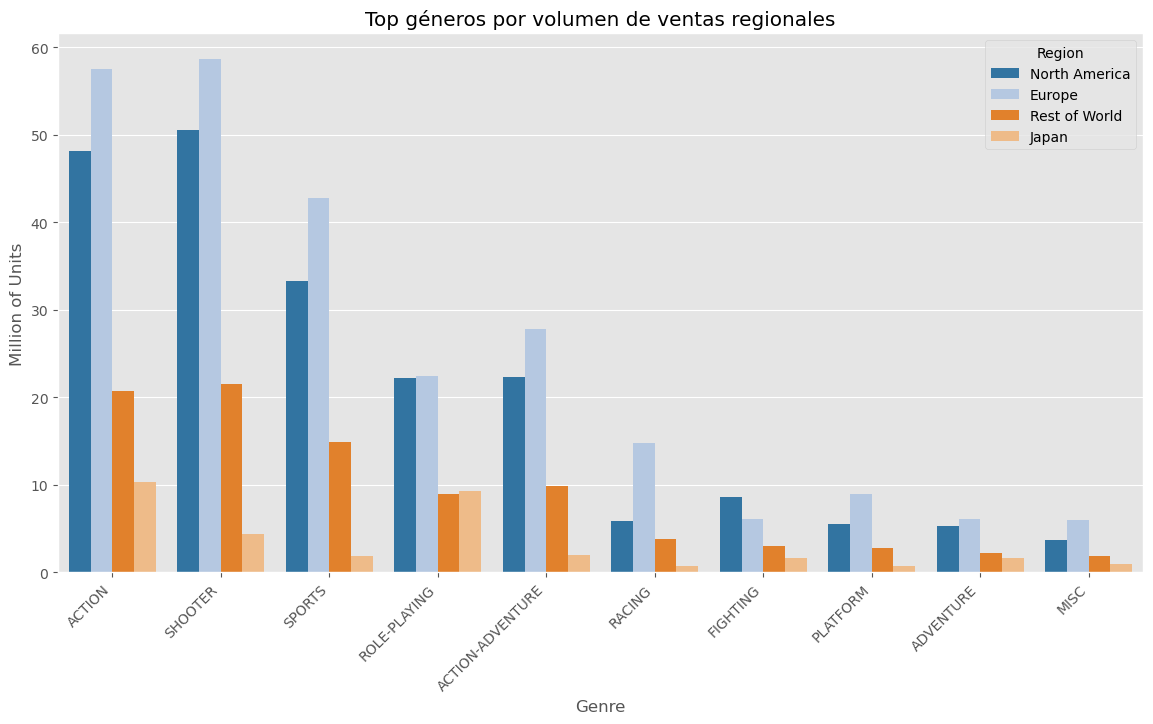

In [49]:
plt.figure(figsize=(14,7))
sns.barplot(data=df_genres_long,x='Genre',y='Million of Units',hue='Region',palette='tab20')
plt.title('Top géneros por volumen de ventas regionales')
plt.xticks(rotation=45, ha='right')
plt.show()

#### <i> Los géneros predominantes en todas las regiones son Acción, Shooters y Deportivos, por lo que se justifica una alta inversión en publicidad para estos, sobre todo en Europa y Norte América. Por otra parte, Japón destaca por su preferencia en juegos de Role-Playing, un fenómeno similar se observa en el género de carreras, que tiene una marcada preferencia por el mercado Europeo. Para ambos casos se sugiere una inversión publicitaria focalizada <i>

## 5.2. Análisis 2: Contribución Regional por Género

Region               Europe      Japan  North America  Rest of World
Genre                                                               
ACTION            42.033328   7.506213      35.192223      15.173220
ACTION-ADVENTURE  44.924022   3.168445      36.049143      15.890721
ADVENTURE         39.947438  10.775296      34.625493      14.651774
FIGHTING          31.559917   8.626033      44.318182      15.340909
MISC              48.356055   7.698476      29.190056      14.835605


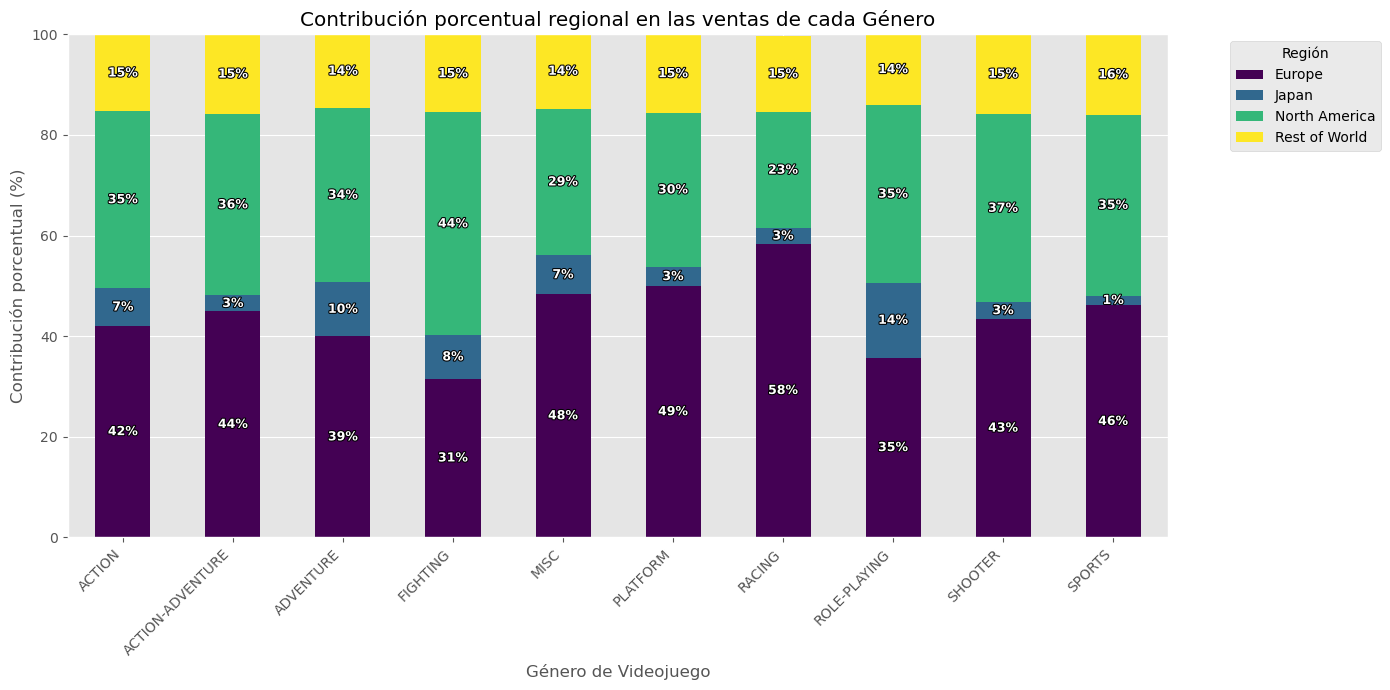

In [76]:
import matplotlib.patheffects as pe

df_wide=df_porcentaje_long.pivot(index='Genre',columns='Region',values='contribucion_region')
print(df_wide.head())
plt.figure(figsize=(14,7))


ax=plt.gca()
df_wide.plot(kind='bar',stacked=True,ax=ax,colormap='viridis',legend=True)
#sns.barplot(data=df_porcentaje_long,x='Genre',y='contribucion_region',hue='Region',palette='viridis',dodge=False)
plt.title('Contribución porcentual regional en las ventas de cada Género')
plt.xlabel('Género de Videojuego')
plt.ylabel('Contribución porcentual (%)')
plt.xticks(rotation=45,ha='right')
plt.legend(title='Región',bbox_to_anchor=(1.05,1),loc='upper left')
plt.ylim(0,100)
plt.tight_layout()

# el siguiente segmento añade los porcentajes en forma de texto sobre las barras apiladas
for rect in ax.patches:
    height=rect.get_height()
    width=rect.get_width()
    x=rect.get_x()
    y=rect.get_y()
    label_text=f'{int(height)}%'
    label_x=x+width/2
    label_y=y+height/2
    ax.text(label_x,
            label_y,
            label_text,
            ha='center',
            va='center',
            fontsize=9,
            color='White',
            fontweight='bold',
            path_effects=[pe.Stroke(linewidth=1.5,foreground='black'),pe.Normal()])
plt.show()

#### <i>La contribución porcentual de japón se enfoque principalmente en tres géneros: fighting, adventure y role-playing. Por lo que los esfuerzos de marketing deben privilegiarse para esta región y géneros específicos. Esto es de especial importancia, considerando que Japón es un mercado que cuenta con competidores de alto calibre como Nintendo y un patrón cultural muy diferente al de occidente. Por otra parte, el género Sports cuenta con una de las contribuciones más bajas por parte de Japón por lo que se sugiere descontinuar la inversión publicitaria para este género.
#### <i>El resto del mundo como región es bastante consistente en la contribución a los géneros de videojuegos de manera transversal, no se sugiere hacer un enfoque de nicho sino más bien una promoción generalizada que no requiera una alta inversión.<i>

## 5.3. Análisis 3: Eficiencia de Publishers

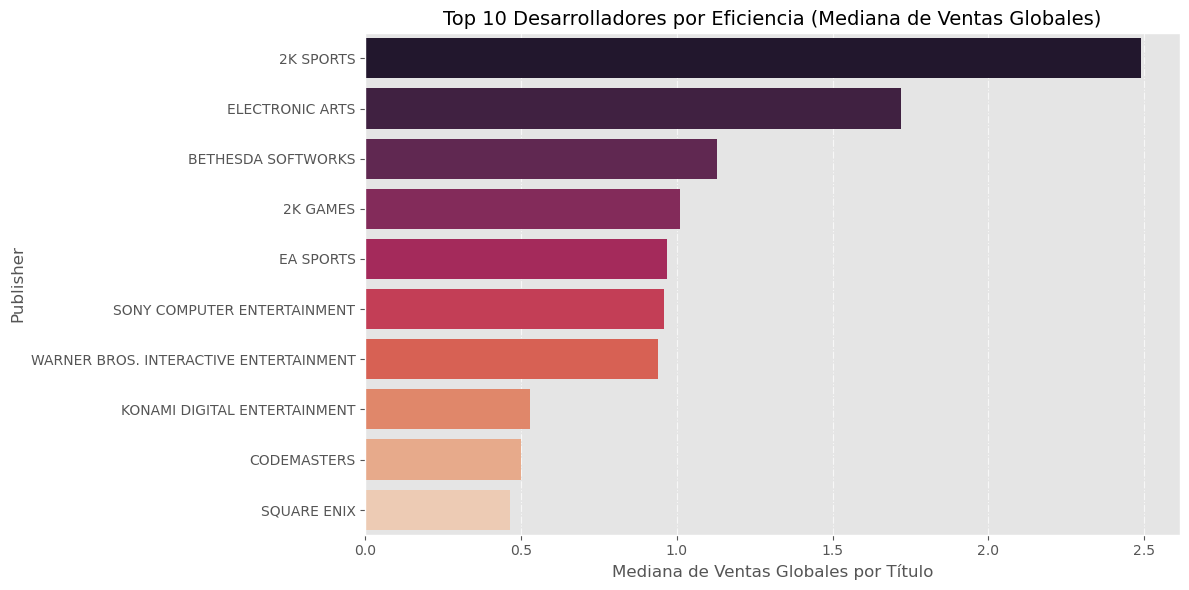

In [123]:
plt.figure(figsize=(12,6))
sns.barplot(data=publishers_top_eficientes,
            x='Ventas_Globales_Mediana',
            y=publishers_top_eficientes.index,
            hue='Publisher',
            palette='rocket')
plt.title('Top 10 Desarrolladores por Eficiencia (Mediana de Ventas Globales)',fontsize=14)
plt.xlabel('Mediana de Ventas Globales por Título')
plt.ylabel('Publisher')
plt.grid(axis='x', linestyle='-.', alpha=0.7)
plt.tight_layout()
plt.show()

#### <i> Podemos observar los 10 publishers más eficientes considerando las ventas medianas conseguidas de manera global. Se sugiere mantener alianzas estratégicas o renovar contratos ya que sus métodos de trabajo han logrado un éxito consistente más allá de algunos éxitos esporádicos. Esta acción es una buena estratégia para reducir el riesgo ya que se confia en empresas con una sólida estructura de trabajo a la vez que una gran gestión de la propiedad intelectual.

## 5.4. Análisis ABC Pareto de Títulos PS4

<img src=https://www.erp-information.com/wp-content/uploads/2019/07/abc-graph-1024x757.jpg>

In [97]:
print('--- Resumen Cuantitativo del Análisis ABC ---')
print(resumen_abc.to_markdown(index=False))

--- Resumen Cuantitativo del Análisis ABC ---
| Clase ABC   |   Num_Juegos |   Ventas_Totales |   contribucion_total_pct |   Pct_Juegos |
|:------------|-------------:|-----------------:|-------------------------:|-------------:|
| A           |           95 |           415.64 |                  69.8062 |      11.5291 |
| B           |          134 |           120.08 |                  20.1673 |      16.2621 |
| C           |          595 |            59.7  |                  10.0265 |      72.2087 |


In [100]:
print('\n Top 10 Títulos de Clase A (Máxima prioridad) ---')
clase_a=df_pareto[df_pareto['Clase ABC']=='A']
print(clase_a[['Game','Global','porcentaje_acumulado']].head(10).to_markdown(index=False))


 Top 5 Títulos de Clase A (Máxima prioridad) ---
| Game                           |   Global |   porcentaje_acumulado |
|:-------------------------------|---------:|-----------------------:|
| Grand Theft Auto V             |    19.39 |                3.25652 |
| Call of Duty: Black Ops 3      |    15.09 |                5.79087 |
| Red Dead Redemption 2          |    13.94 |                8.13207 |
| Call of Duty: WWII             |    13.4  |               10.3826  |
| FIFA 18                        |    11.8  |               12.3644  |
| FIFA 17                        |    10.94 |               14.2017  |
| Uncharted (PS4)                |    10.33 |               15.9366  |
| Spider-Man (PS4)               |     8.76 |               17.4079  |
| Call of Duty: Infinite Warfare |     8.48 |               18.8321  |
| Fallout 4                      |     8.48 |               20.2563  |


In [102]:
print('\n --- 10 Títulos de Clase C (Baja contribución alto Riesgo) ---')
clase_c=df_pareto[df_pareto['Clase ABC']=='C']
print(clase_c[['Game','Global','porcentaje_acumulado']].tail(10).to_markdown(index=False))


 --- 10 Títulos de Clase C (Baja contribución alto Riesgo) ---
| Game                       |   Global |   porcentaje_acumulado |
|:---------------------------|---------:|-----------------------:|
| Rocketbirds 2: Evolution   |        0 |                    100 |
| Carmageddon: Reincarnation |        0 |                    100 |
| Contrast                   |        0 |                    100 |
| Final Fantasy (PS4)        |        0 |                    100 |
| Cyberpunk 2077             |        0 |                    100 |
| Whore of the Orient        |        0 |                    100 |
| Human Element              |        0 |                    100 |
| deep down (Working Title)  |        0 |                    100 |
| Slender: The Arrival       |        0 |                    100 |
| Radial G Racing Revolved   |        0 |                    100 |


#### <i>Los Títulos de la categoría A deben recibir el mayor presupuesto publicitario, priorizando altos niveles de stock y el trabajo en el desarrollo de secuelas, remakes, spin-offs, o expansiones.
#### <i> Aquellos títulos pertenecientes a la clase C que constituye muy alto porcentaje de juegos, representa menos del 10% de las ventas, por lo que se sugiere una estratégia de desinversión. Reducir los niveles de stock, o vender los derechos de propiedad intelectual para liberar recursos operativos y financieros.

In [107]:
# creación de un cuadro resumen
datos_hallazgos={'Análisis':['5.1/5.2 (Género/Región)','5.3 (Eficiencia Publishers)','5.4 (ABC/Pareto Títulos)'],'Métrica Clave':['Contribución Porcentual','Mediana de Ventas','Porcentaje de Inventario'],
                 'Hallazgo Cuantitativo':['los géneros Shooter y acciones (más populares) reciben más del 70%  sus ventas globales desde la América del Norte y Europa','Rockstar Games tiene la mediana más alta ($[13.94]$ millones de unidades vendidas).','Solo el 12% de los títulos (Clase A) generan el 70% de las ventas totales.'],
                 'Implicacion estratégica (Conclusión)':['La inversión en marketing debe ser hiper-localizada en Japón.','Este Publisher representa el socio de menor riesgo y mayor consistencia para futuras asignaciones de presupuesto.','Concentrar el 70% del presupuesto operativo y publicitario en la Clase A; desinversión/descontinuación de la Clase C.']}
df_hallazgos=pd.DataFrame(datos_hallazgos)

## RESUMEN EJECUTIVO: HALLAZGOS Y ESTRATEGIA

In [115]:
df_hallazgos

,Análisis,Métrica Clave,Hallazgo Cuantitativo,Implicacion estratégica (Conclusión)
0,5.1/5.2 (Género/Región),Contribución Porcentual,los géneros Shooter y acciones (más populares)...,La inversión en marketing debe ser hiper-local...
1,5.3 (Eficiencia Publishers),Mediana de Ventas,Rockstar Games tiene la mediana más alta ($[13...,Este Publisher representa el socio de menor ri...
2,5.4 (ABC/Pareto Títulos),Porcentaje de Inventario,Solo el 12% de los títulos (Clase A) generan e...,Concentrar el 70% del presupuesto operativo y ...


# Etapa 6: Actuar

<img src="Etapa_6_Propuestas/Slide_1.jpg">

<img src="Etapa_6_Propuestas/Slide_2.jpg">

<img src="Etapa_6_Propuestas/Slide_3.jpg">

<img src="Etapa_6_Propuestas/Slide_4.jpg">

<img src="Etapa_6_Propuestas/Slide_5.jpg">

<img src="Etapa_6_Propuestas/Slide_6.jpg">